# Part 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import string
import re

# Part 2: Load dataset

In [2]:
df = pd.read_csv('../dataset/spam.csv', encoding='latin-1')
df = df.iloc[:, :2]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Part 2.1: Class Distribution Plot

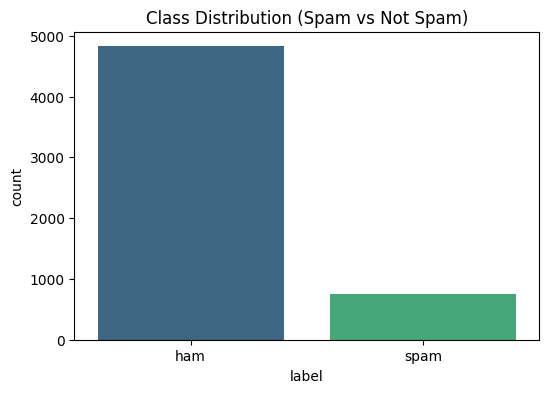

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Class Distribution (Spam vs Not Spam)')
plt.show()

# Part 3: Preprocess Text

In [4]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    stopwords = set(["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"])
    words = text.split()
    words = [w for w in words if w not in stopwords]
    return " ".join(words)

df['processed_message'] = df['message'].apply(preprocess_text)
df.head()

,label,message,processed_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


# Part 4: Feature Extraction

In [5]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['processed_message'])
y = df['label'].map({'spam': 1, 'ham': 0})

# Part 5: Split Dataset

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Part 6: Train Model

In [7]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

# Part 7: Evaluate

In [8]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9659192825112107

Confusion Matrix:
 [[965   0]
 [ 38 112]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



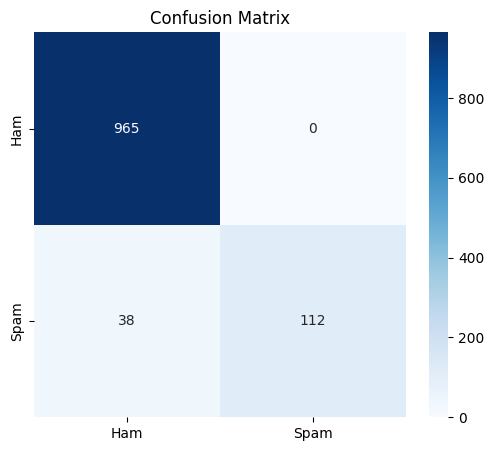

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.show()

# Part 8: Custom Testing

In [10]:
custom_test = ["Congratulations! You won ₹10000"]
processed_test = [preprocess_text(msg) for msg in custom_test]
custom_X = vectorizer.transform(processed_test)
custom_pred = model.predict(custom_X)

print("Input:", custom_test[0])
print("Prediction:", "Spam" if custom_pred[0] == 1 else "Not Spam")

Input: Congratulations! You won ₹10000
Prediction: Spam
